# George vs i-PI Harmonic Friction Benchmark

This notebook reproduces a direct benchmark between:

- **George's analytical result** for thermal time-correlation functions of a 1D harmonic oscillator with position-independent friction
- **i-PI** for the matching static Markovian electronic-friction model

The goal is to compare the normalized thermal correlation functions

$$
C_{qq}(t), \qquad C_{qp}(t), \qquad C_{pp}(t)
$$

between the two approaches and generate the overlay figure automatically.

## Model and parameter mapping

George's notebook uses a Brownian harmonic oscillator with:

- mass $m = 1$
- frequency $\omega = 1$
- reciprocal temperature $\beta = 1$
- Markovian drift block
  $$
  A_p = [\gamma]
  $$

In the current i-PI static-friction implementation,

$$
\gamma = \sigma_{\mathrm{static}}^2.
$$

So for George's default

$$
A_p = 0.25
$$

the matching i-PI choice is

$$
\sigma_{\mathrm{static}} = \sqrt{0.25} = 0.5.
$$

We compare **normalized** TCFs first, because that isolates the shape and timescale of the dynamics:

$$
\tilde C_{qq}(t) = \frac{C_{qq}(t)}{C_{qq}(0)}, \qquad
\tilde C_{pp}(t) = \frac{C_{pp}(t)}{C_{pp}(0)}, \qquad
\tilde C_{qp}(t) = \frac{C_{qp}(t)}{\sqrt{C_{qq}(0) C_{pp}(0)}}.
$$

## What this notebook does

1. Imports George's analytical OU function from the sibling `rpgle-model-dynamics` tree
2. Runs i-PI for a 1-atom, 1-bead harmonic oscillator with static friction
3. Estimates the TCFs from the i-PI trajectory
4. Overlays i-PI and George analytical curves
5. Writes the same benchmark figure and an error table
6. Extends the benchmark to a Brownian double-well model using George's
   numerical reference dynamics

This is intended to be a **common benchmark notebook** for future friction development.

In [81]:
import csv
import os
import shutil
import subprocess
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd()
if not (ROOT / "init.xyz").exists():
    raise RuntimeError("Run this notebook from ipi_harmonic_tcf_benchmark/")

from rpmdgle.utils import ou

import ipi

PYTHON_EXEC = Path(sys.executable).resolve()
RUNS = ROOT / "runs"
RUNS.mkdir(exist_ok=True)

print("Notebook root:", ROOT)
print("i-PI repo:", IPI_REPO)
print("ipi package:", Path(ipi.__file__).resolve())
print("Python executable:", PYTHON_EXEC)
print("rpgle root:", RPGLE_ROOT)

Notebook root: /Users/u1865573/work/2026/friction-ipi/04_george_code_benchmark/ipi_harmonic_tcf_benchmark
i-PI repo: /Users/u1865573/work/2026/i-pi
ipi package: /Users/u1865573/work/2026/i-pi/ipi/__init__.py
Python executable: /Users/u1865573/miniconda3/envs/CUDA-torch-base/bin/python3.10
rpgle root: /Users/u1865573/work/2026/friction-ipi/04_george_code_benchmark/rpgle-model-dynamics


## Benchmark parameters

The benchmark should be controlled in **physical time**, not in raw step count.

So we specify:

- `total_time`
- `burn_time`

and derive the number of MD steps separately for each timestep.

In [82]:
mass = 1.0
omega = 1.0
beta = 1.0
ap = 0.25
sigma_static = np.sqrt(ap)

dt_list = [0.10, 0.05, 0.02]
total_time = 4000.0
burn_time = 500.0
max_time = 10.0
temperature_k = 300.0
runtime_timeout_s = 1800
driver_shutdown_timeout_s = 120

print("sigma_static =", sigma_static)

sigma_static = 0.5


In [83]:
        def require_path(path: Path | None, label: str) -> Path:
            if path is None or not path.exists():
                raise FileNotFoundError(f"Could not locate {label}: {path}")
            return path


        def read_xyz_series(path: Path):
            labels = None
            frames = []
            with path.open() as handle:
                while True:
                    line = handle.readline()
                    if not line:
                        break
                    nat = int(line.strip())
                    handle.readline()
                    coords = []
                    current_labels = []
                    for _ in range(nat):
                        parts = handle.readline().split()
                        current_labels.append(parts[0])
                        coords.append([float(parts[1]), float(parts[2]), float(parts[3])])
                    if labels is None:
                        labels = np.array(current_labels)
                    frames.append(coords)
            return np.array(labels), np.asarray(frames, dtype=float)


        def estimate_tcf(a: np.ndarray, b: np.ndarray, max_lag: int) -> np.ndarray:
            a = np.asarray(a, dtype=float) - np.mean(a)
            b = np.asarray(b, dtype=float) - np.mean(b)
            n = len(a)
            size = 1 << (2 * n - 1).bit_length()
            fa = np.fft.rfft(a, size)
            fb = np.fft.rfft(b, size)
            corr = np.fft.irfft(fa * np.conj(fb), size)[:n]
            norm = np.arange(n, 0, -1, dtype=float)
            return corr[:max_lag] / norm[:max_lag]


        def normalize_tcfs(cqq: np.ndarray, cqp: np.ndarray, cpp: np.ndarray):
            q0 = cqq[0]
            p0 = cpp[0]
            scale = np.sqrt(q0 * p0)
            return cqq / q0, cqp / scale, cpp / p0


        def write_input_xml(path: Path, dt_au: float, nsteps: int, sigma_static: float, temp_k: float):
            path.write_text(
                f"""<simulation verbosity='low'>
  <output prefix='harmonic'>
    <properties stride='1' filename='out'>[
      step, time{{atomic_unit}}, potential, kinetic_md, friction_ediss
    ]</properties>
    <trajectory filename='pos' stride='1'>positions</trajectory>
    <trajectory filename='mom' stride='1'>momenta</trajectory>
  </output>
  <total_steps>{nsteps}</total_steps>
  <prng><seed>31415</seed></prng>
  <ffsocket name='harm' mode='unix' pbc='false'>
    <address>harmonic_socket</address>
  </ffsocket>
  <system>
    <initialize nbeads='1'>
      <file mode='xyz'>init.xyz</file>
      <masses mode='manual'>[1.0]</masses>
      <velocities mode='thermal' units='kelvin'>{temp_k}</velocities>
      <cell mode='abc' units='angstrom'>[10, 10, 10]</cell>
    </initialize>
    <forces><force forcefield='harm'></force></forces>
    <ensemble><temperature units='kelvin'>{temp_k}</temperature></ensemble>
    <motion mode='dynamics'>
      <fixcom>False</fixcom>
      <dynamics mode='nve-f' splitting='fbabf'>
        <timestep units='atomic_unit'>{dt_au}</timestep>
        <friction>
          <variable_friction>False</variable_friction>
          <sigma_static>{sigma_static}</sigma_static>
          <bath_mode>markovian</bath_mode>
        </friction>
      </dynamics>
    </motion>
  </system>
</simulation>
"""
            )


        def run_ipi_case(run_dir: Path, dt_au: float):
            if not run_dir.exists():
                run_dir.mkdir(parents=True)
            if not (run_dir / "init.xyz").exists():
                shutil.copy2(ROOT / "init.xyz", run_dir / "init.xyz")
            if (run_dir / "harmonic.out").exists():
                print(f"Reusing existing output for dt={dt_au}: {run_dir / 'harmonic.out'}")
                return

            nsteps = int(round(total_time / dt_au))
            write_input_xml(run_dir / "input.xml", dt_au, nsteps, sigma_static, temperature_k)

            env = os.environ.copy()
            env.setdefault("PYTHONUNBUFFERED", "1")
            env["PYTHONPATH"] = str(IPI_REPO) + (
                os.pathsep + env["PYTHONPATH"] if "PYTHONPATH" in env and env["PYTHONPATH"] else ""
            )
            env["PATH"] = str(IPI_REPO / "bin") + (
                os.pathsep + env["PATH"] if "PATH" in env and env["PATH"] else ""
            )

            ipi_process = None
            driver_process = []
            with (run_dir / "ipi.log").open("w") as ipi_log, (run_dir / "driver.log").open("w") as drv_log:
                ipi_process = subprocess.Popen(
                    ["i-pi", "input.xml"],
                    cwd=run_dir,
                    stdout=ipi_log,
                    stderr=subprocess.STDOUT,
                    env=env,
                )
                time.sleep(4.0)
                driver_process = [
                    subprocess.Popen(
                        [
                            "i-pi-py_driver",
                            "-m",
                            "harmonic",
                            "-o",
                            "1.0",
                            "-u",
                            "-a",
                            "harmonic_socket",
                        ],
                        cwd=run_dir,
                        stdout=drv_log,
                        stderr=subprocess.STDOUT,
                        env=env,
                    )
                ]

                if ipi_process is not None:
                    try:
                        ipi_rc = ipi_process.wait(timeout=runtime_timeout_s)
                        if ipi_rc != 0:
                            raise RuntimeError(f"i-PI failed for dt={dt_au}. Check {run_dir/'ipi.log'}")
                        driver_process[0].wait(timeout=driver_shutdown_timeout_s)
                    finally:
                        if ipi_process.poll() is None:
                            ipi_process.terminate()
                        if driver_process and driver_process[0].poll() is None:
                            driver_process[0].terminate()


        def load_series(run_dir: Path, dt_au: float):
            _, pos = read_xyz_series(run_dir / "harmonic.pos_0.xyz")
            _, mom = read_xyz_series(run_dir / "harmonic.mom_0.xyz")
            burn = int(round(burn_time / dt_au))
            return pos[burn:, 0, 0], mom[burn:, 0, 0]

## George analytical reference

This cell computes the reference curves directly from George's OU implementation.

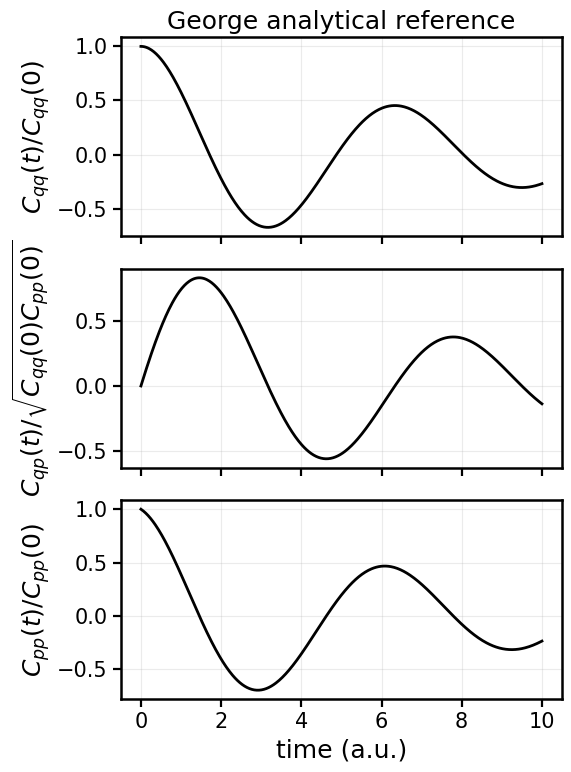

In [84]:
tref = np.linspace(0.0, max_time, 500)
ref = ou.gle_cxx(tref, omega, np.array([[ap]]), beta=beta, mass=mass)

cqq_ref = np.asarray(ref[..., 0, 0], dtype=float)
cqp_ref = np.asarray(ref[..., 0, 1], dtype=float)
cpp_ref = np.asarray(ref[..., 1, 1], dtype=float)
cqq_ref_n, cqp_ref_n, cpp_ref_n = normalize_tcfs(cqq_ref, cqp_ref, cpp_ref)

fig, axes = plt.subplots(3, 1, figsize=(6, 8), sharex=True)
axes[0].plot(tref, cqq_ref_n, color="black", lw=2)
axes[1].plot(tref, cqp_ref_n, color="black", lw=2)
axes[2].plot(tref, cpp_ref_n, color="black", lw=2)
axes[0].set_title("George analytical reference")
axes[0].set_ylabel(r"$C_{qq}(t) / C_{qq}(0)$")
axes[1].set_ylabel(r"$C_{qp}(t) / \sqrt{C_{qq}(0) C_{pp}(0)}$")
axes[2].set_ylabel(r"$C_{pp}(t) / C_{pp}(0)$")
axes[2].set_xlabel("time (a.u.)")
for ax in axes:
    ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## Run i-PI

This cell launches the i-PI harmonic benchmark for all timesteps in `dt_list`.

The notebook adds the local `i-pi` repository to `PYTHONPATH` and prepends
its `bin/` directory to `PATH`, so the external `i-pi` and `i-pi-py_driver`
processes use the modified local checkout rather than any unrelated install.

If a run directory already contains `harmonic.out`, the launch helper skips
that case so you can rerun the notebook without restarting finished jobs.

In [85]:
for dt_au in dt_list:
    run_dir = RUNS / f"dt_{dt_au:.4f}".replace(".", "p")
    print("Running dt =", dt_au, "in", run_dir)
    run_ipi_case(run_dir, dt_au)

Running dt = 0.1 in /Users/u1865573/work/2026/friction-ipi/04_george_code_benchmark/ipi_harmonic_tcf_benchmark/runs/dt_0p1000
Reusing existing output for dt=0.1: /Users/u1865573/work/2026/friction-ipi/04_george_code_benchmark/ipi_harmonic_tcf_benchmark/runs/dt_0p1000/harmonic.out
Running dt = 0.05 in /Users/u1865573/work/2026/friction-ipi/04_george_code_benchmark/ipi_harmonic_tcf_benchmark/runs/dt_0p0500
Reusing existing output for dt=0.05: /Users/u1865573/work/2026/friction-ipi/04_george_code_benchmark/ipi_harmonic_tcf_benchmark/runs/dt_0p0500/harmonic.out
Running dt = 0.02 in /Users/u1865573/work/2026/friction-ipi/04_george_code_benchmark/ipi_harmonic_tcf_benchmark/runs/dt_0p0200
Reusing existing output for dt=0.02: /Users/u1865573/work/2026/friction-ipi/04_george_code_benchmark/ipi_harmonic_tcf_benchmark/runs/dt_0p0200/harmonic.out


## Analyse and plot George vs i-PI

We now estimate the TCFs from the i-PI trajectories and overlay them with the analytical curves.

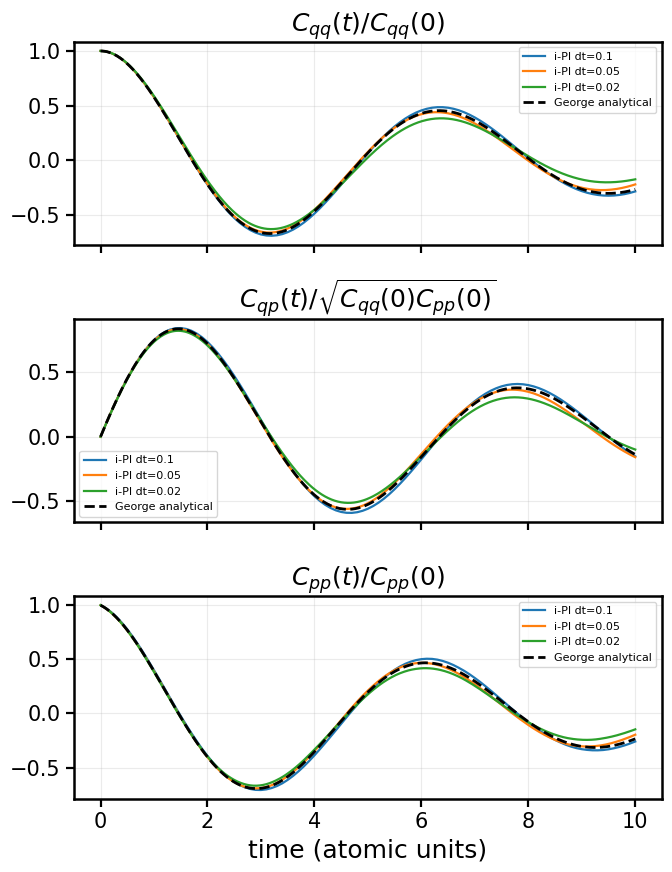

In [86]:
results = []

fig, axes = plt.subplots(3, 1, figsize=(7, 9), sharex=True)
labels = [
    r"$C_{qq}(t) / C_{qq}(0)$",
    r"$C_{qp}(t) / \sqrt{C_{qq}(0) C_{pp}(0)}$",
    r"$C_{pp}(t) / C_{pp}(0)$",
]
for ax, label in zip(axes, labels):
    ax.set_title(label)
    ax.grid(alpha=0.25)

for dt_au in dt_list:
    run_dir = RUNS / f"dt_{dt_au:.4f}".replace(".", "p")
    x, p = load_series(run_dir, dt_au)
    max_lag = min(len(x) // 4, int(max_time / dt_au) + 1)
    t = np.arange(max_lag) * dt_au

    cqq = estimate_tcf(x, x, max_lag)
    cqp = estimate_tcf(x, p, max_lag)
    cpp = estimate_tcf(p, p, max_lag)
    cqq_n, cqp_n, cpp_n = normalize_tcfs(cqq, cqp, cpp)

    ref_local = ou.gle_cxx(t, omega, np.array([[ap]]), beta=beta, mass=mass)
    cqq_local = np.asarray(ref_local[..., 0, 0], dtype=float)
    cqp_local = np.asarray(ref_local[..., 0, 1], dtype=float)
    cpp_local = np.asarray(ref_local[..., 1, 1], dtype=float)
    cqq_local_n, cqp_local_n, cpp_local_n = normalize_tcfs(cqq_local, cqp_local, cpp_local)

    err_qq = np.sqrt(np.mean((cqq_n - cqq_local_n) ** 2))
    err_qp = np.sqrt(np.mean((cqp_n - cqp_local_n) ** 2))
    err_pp = np.sqrt(np.mean((cpp_n - cpp_local_n) ** 2))
    results.append((dt_au, err_qq, err_qp, err_pp))

    axes[0].plot(t, cqq_n, lw=1.6, label=f"i-PI dt={dt_au}")
    axes[1].plot(t, cqp_n, lw=1.6, label=f"i-PI dt={dt_au}")
    axes[2].plot(t, cpp_n, lw=1.6, label=f"i-PI dt={dt_au}")

axes[0].plot(tref, cqq_ref_n, color="black", ls="--", lw=2.0, label="George analytical")
axes[1].plot(tref, cqp_ref_n, color="black", ls="--", lw=2.0, label="George analytical")
axes[2].plot(tref, cpp_ref_n, color="black", ls="--", lw=2.0, label="George analytical")

axes[2].set_xlabel("time (atomic units)")
for ax in axes:
    ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig(ROOT / "harmonic_tcf_benchmark.png", dpi=200)
plt.show()

In [87]:
with (ROOT / "harmonic_tcf_errors.csv").open("w", newline="") as handle:
    writer = csv.writer(handle)
    writer.writerow(["dt_au", "rms_cqq", "rms_cqp", "rms_cpp"])
    writer.writerows(results)

print("Wrote:", ROOT / "harmonic_tcf_benchmark.png")
print("Wrote:", ROOT / "harmonic_tcf_errors.csv")
print()
print("Error summary")
for dt_au, err_qq, err_qp, err_pp in results:
    print(f"dt={dt_au:8.4f}  rms(Cqq)={err_qq:.6e}  rms(Cqp)={err_qp:.6e}  rms(Cpp)={err_pp:.6e}")

Wrote: /Users/u1865573/work/2026/friction-ipi/04_george_code_benchmark/ipi_harmonic_tcf_benchmark/harmonic_tcf_benchmark.png
Wrote: /Users/u1865573/work/2026/friction-ipi/04_george_code_benchmark/ipi_harmonic_tcf_benchmark/harmonic_tcf_errors.csv

Error summary
dt=  0.1000  rms(Cqq)=1.730265e-02  rms(Cqp)=1.818961e-02  rms(Cpp)=2.182024e-02
dt=  0.0500  rms(Cqq)=1.615933e-02  rms(Cqp)=1.798307e-02  rms(Cpp)=1.597456e-02
dt=  0.0200  rms(Cqq)=5.085614e-02  rms(Cqp)=3.807714e-02  rms(Cpp)=3.700650e-02


## Double well benchmark: George numerical vs i-PI

The harmonic oscillator gives an analytical target. The next useful test is
the **Brownian double well**, where George already has a numerical reference
notebook.

Here we compare:

- **George numerical double well dynamics** from `rpmdgle`
- **i-PI** with the matching double-well potential and a constant static
  Markovian friction

We keep the friction position independent by using the plain `DW` driver in
i-PI and choosing

$$
\gamma = \eta_0, \qquad \sigma_{\mathrm{static}} = \sqrt{\eta_0}.
$$

For the position correlation we compare the **centered covariance**

$$
C_{xx}(t) = \langle \delta x(t)\,\delta x(0)\rangle,
\qquad
\delta x = x - \langle x \rangle,
$$

on both sides. This matters for the double well, where the raw
uncentered autocorrelation can stay close to 1 if the trajectory remains
trapped in one well over the lag-time window.

The comparison is numerical-versus-numerical, so the two curves will not be
identical point by point. The goal is to check that they show the same
relaxation pattern and timescale.

In [88]:
from rpmdgle.units import atomic
from rpmdgle.pes.polynomial import PES as DWell
from rpmdgle.pes.pi import Ring
from rpmdgle.propagators.langevin import RingPILE
from rpmdgle.utils.tcfs import time_averaged_correlation

u = atomic()

dw_wb_cm = 500.0
dw_v0_cm = 2085.0
dw_mass = 1837.36223469
dw_delta_ang = 0.0
dw_eta0 = 5.0
dw_sigma_static = np.sqrt(dw_eta0)
dw_temperature_k = 300.0

# George numerical reference parameters
dw_beta = u.betaTemp(dw_temperature_k)
dw_n_beads = 1
dw_n_replicas = 100
dw_dt_fs = 0.5
dw_dt_au = u.str2base(f"{dw_dt_fs} fs")
dw_sampling_tau_fs = 25.0
dw_relaxation_time_fs = 1000.0
dw_trajectory_time_fs = 3000.0
dw_n_samples = 10
dw_stride = 2
dw_lag_time_fs = 500.0

# i-PI comparison trajectory
dw_total_time_fs = 30000.0
dw_burn_time_fs = 10000.0

print("double well sigma_static =", dw_sigma_static)
print("double well dt (a.u.)    =", dw_dt_au)

double well sigma_static = 2.23606797749979
double well dt (a.u.)    = 20.670686667576422


In [89]:
        def write_doublewell_input_xml(path: Path, dt_au: float, nsteps: int, sigma_static: float, temp_k: float):
            path.write_text(
                f"""<simulation verbosity='low'>
  <output prefix='doublewell'>
    <properties stride='1' filename='out'>[
      step, time{{atomic_unit}}, potential, kinetic_md, friction_ediss
    ]</properties>
    <trajectory filename='pos' stride='1'>positions</trajectory>
    <trajectory filename='mom' stride='1'>momenta</trajectory>
  </output>
  <total_steps>{nsteps}</total_steps>
  <prng><seed>424242</seed></prng>
  <ffsocket name='dw' mode='unix' pbc='false'>
    <address>doublewell_socket</address>
  </ffsocket>
  <system>
    <initialize nbeads='1'>
      <file mode='xyz'>init.xyz</file>
      <masses mode='manual'>[{dw_mass}]</masses>
      <velocities mode='thermal' units='kelvin'>{temp_k}</velocities>
      <cell mode='abc' units='angstrom'>[10, 10, 10]</cell>
    </initialize>
    <forces><force forcefield='dw'></force></forces>
    <ensemble><temperature units='kelvin'>{temp_k}</temperature></ensemble>
    <motion mode='dynamics'>
      <fixcom>False</fixcom>
      <dynamics mode='nve-f' splitting='fbabf'>
        <timestep units='atomic_unit'>{dt_au}</timestep>
        <friction>
          <variable_friction>False</variable_friction>
          <sigma_static>{sigma_static}</sigma_static>
          <bath_mode>markovian</bath_mode>
        </friction>
      </dynamics>
    </motion>
  </system>
</simulation>
"""
            )


        def run_doublewell_ipi_case(run_dir: Path):
            if not run_dir.exists():
                run_dir.mkdir(parents=True)
            if not (run_dir / "init.xyz").exists():
                shutil.copy2(ROOT / "init.xyz", run_dir / "init.xyz")
            if (run_dir / "doublewell.out").exists():
                input_xml = run_dir / "input.xml"
                if input_xml.exists():
                    xml_text = input_xml.read_text()
                    expected_tag = f"<timestep units='atomic_unit'>{dw_dt_au}</timestep>"
                    if expected_tag in xml_text:
                        print(f"Reusing existing double-well output: {run_dir / 'doublewell.out'}")
                        return
                print(f"Removing stale double-well output in {run_dir}")
                shutil.rmtree(run_dir)
                run_dir.mkdir(parents=True)
                shutil.copy2(ROOT / "init.xyz", run_dir / "init.xyz")

            nsteps = int(round(u.str2base(f"{dw_total_time_fs} fs") / dw_dt_au))
            write_doublewell_input_xml(
                run_dir / "input.xml",
                dw_dt_au,
                nsteps,
                dw_sigma_static,
                dw_temperature_k,
            )

            env = os.environ.copy()
            env.setdefault("PYTHONUNBUFFERED", "1")
            env["PYTHONPATH"] = str(IPI_REPO) + (
                os.pathsep + env["PYTHONPATH"] if "PYTHONPATH" in env and env["PYTHONPATH"] else ""
            )
            env["PATH"] = str(IPI_REPO / "bin") + (
                os.pathsep + env["PATH"] if "PATH" in env and env["PATH"] else ""
            )

            driver_args = f"{dw_wb_cm},{dw_v0_cm},{dw_mass},{dw_delta_ang}"

            with (run_dir / "ipi.log").open("w") as ipi_log, (run_dir / "driver.log").open("w") as drv_log:
                ipi_process = subprocess.Popen(
                    ["i-pi", "input.xml"],
                    cwd=run_dir,
                    stdout=ipi_log,
                    stderr=subprocess.STDOUT,
                    env=env,
                )
                time.sleep(4.0)
                driver_process = [
                    subprocess.Popen(
                        [
                            "i-pi-py_driver",
                            "-m",
                            "DW",
                            "-o",
                            driver_args,
                            "-u",
                            "-a",
                            "doublewell_socket",
                        ],
                        cwd=run_dir,
                        stdout=drv_log,
                        stderr=subprocess.STDOUT,
                        env=env,
                    )
                ]

                try:
                    ipi_rc = ipi_process.wait(timeout=runtime_timeout_s)
                    if ipi_rc != 0:
                        raise RuntimeError(f"double-well i-PI failed. Check {run_dir/'ipi.log'}")
                    driver_process[0].wait(timeout=driver_shutdown_timeout_s)
                finally:
                    if ipi_process.poll() is None:
                        ipi_process.terminate()
                    if driver_process and driver_process[0].poll() is None:
                        driver_process[0].terminate()


        def load_doublewell_series(run_dir: Path):
            _, pos = read_xyz_series(run_dir / "doublewell.pos_0.xyz")
            _, mom = read_xyz_series(run_dir / "doublewell.mom_0.xyz")
            burn = int(round(u.str2base(f"{dw_burn_time_fs} fs") / dw_dt_au))
            pos = pos[burn::dw_stride, 0, 0]
            mom = mom[burn::dw_stride, 0, 0]
            if len(pos) == 0 or len(mom) == 0:
                raise RuntimeError(
                    f"Double-well trajectory is empty after burn-in. "
                    f"burn={burn} frames, available={len(read_xyz_series(run_dir / 'doublewell.pos_0.xyz')[1])}. "
                    f"Rerun the double-well launch cell for the current timestep."
                )
            return pos, mom

### George numerical double-well reference

This reproduces George's `thermal_tcfs.ipynb` setup: a quartic double well,
classical dynamics (`n_beads = 1`), and Brownian dynamics generated with
`RingPILE`.

In [90]:
dw_coeffs = [
    0.0,
    0.0,
    -dw_mass * u.wn2omega(dw_wb_cm) ** 2 / 2,
    0.0,
    dw_mass**2 * u.wn2omega(dw_wb_cm) ** 4 / (16 * u.wn2energy(dw_v0_cm)),
]
dw_pes = DWell(mass=dw_mass, coeffs=dw_coeffs, UNITS=u.__class__.__name__)
dw_rp_pes = Ring(dw_n_beads, (1,), dw_pes, dw_beta)

seed = 31415
ss = np.random.SeedSequence(seed)
rng_seed_0, rng_seed_1 = ss.spawn(2)

x = np.zeros((dw_n_replicas, dw_n_beads, 1))
p = np.zeros_like(x)

sampling_propagator = RingPILE(
    dw_rp_pes,
    dw_dt_au,
    x.shape,
    rng_seed_0,
    dw_beta,
    u.str2base(f"{dw_sampling_tau_fs} fs"),
)
sampling_propagator.set_x(x)
rng = sampling_propagator.rng
sampling_propagator.set_p(rng.normal(scale=np.sqrt(dw_mass / dw_beta), size=p.shape))

production_propagator = RingPILE(
    dw_rp_pes,
    dw_dt_au,
    x.shape,
    rng_seed_1,
    dw_beta,
    (dw_eta0 / dw_mass) ** (-1),
)

n_relaxation_steps = int(u.str2base(f"{dw_relaxation_time_fs} fs") / dw_dt_au)
n_production_steps = int(u.str2base(f"{dw_trajectory_time_fs} fs") / dw_dt_au)
dw_tcf_time_step = dw_stride * dw_dt_au
dw_n_lag = int(u.str2base(f"{dw_lag_time_fs} fs") / dw_tcf_time_step)

dw_cxx = np.zeros((dw_n_lag + 1, dw_n_replicas))
dw_cpp = np.zeros_like(dw_cxx)
for _ in range(dw_n_samples):
    sampling_propagator.step(s=n_relaxation_steps)
    production_propagator.set_pnm(production_propagator.psample(dw_beta))
    production_propagator.set_xnm(sampling_propagator.xnm.copy())

    positions = [production_propagator.xnm[:, 0, 0].copy()]
    momenta = [production_propagator.pnm[:, 0, 0].copy()]
    for _ in range(0, n_production_steps, dw_stride):
        production_propagator.step(s=dw_stride)
        positions.append(production_propagator.xnm[:, 0, 0].copy())
        momenta.append(production_propagator.pnm[:, 0, 0].copy())

    sampling_propagator.set_xnm(production_propagator.xnm.copy())
    sampling_propagator.set_pnm(production_propagator.psample(dw_beta))

    positions = np.stack(positions, axis=0)
    positions = positions - positions.mean(axis=0, keepdims=True)
    momenta = np.stack(momenta, axis=0)
    momenta = momenta - momenta.mean(axis=0, keepdims=True)
    dw_cxx += time_averaged_correlation(positions, positions, dw_n_lag, axis=0)
    dw_cpp += time_averaged_correlation(momenta, momenta, dw_n_lag, axis=0)

dw_cxx /= dw_n_samples
dw_cpp /= dw_n_samples
dw_cxx_ref = dw_cxx.mean(axis=-1)
dw_cpp_ref = dw_cpp.mean(axis=-1)
dw_cxx_ref_n, _, dw_cpp_ref_n = normalize_tcfs(dw_cxx_ref, np.zeros_like(dw_cxx_ref), dw_cpp_ref)

dw_t_ref_fs = np.arange(dw_n_lag + 1) * dw_tcf_time_step / u.str2base("1 fs")

### i-PI double-well comparison run

We now run the same double-well potential in i-PI using the plain `DW`
driver and constant static friction. The `sigma_static` choice is matched to
George's `eta0` through `gamma = sigma_static^2 = eta0`.

In [91]:
dw_run_dir = RUNS / f"doublewell_static_eta5_dt_{dw_dt_fs:.4f}".replace(".", "p")
print("Running double well in", dw_run_dir)
run_doublewell_ipi_case(dw_run_dir)

Running double well in /Users/u1865573/work/2026/friction-ipi/04_george_code_benchmark/ipi_harmonic_tcf_benchmark/runs/doublewell_static_eta5_dt_0p5000
Reusing existing double-well output: /Users/u1865573/work/2026/friction-ipi/04_george_code_benchmark/ipi_harmonic_tcf_benchmark/runs/doublewell_static_eta5_dt_0p5000/doublewell.out


### Plot George numerical vs i-PI for the double well

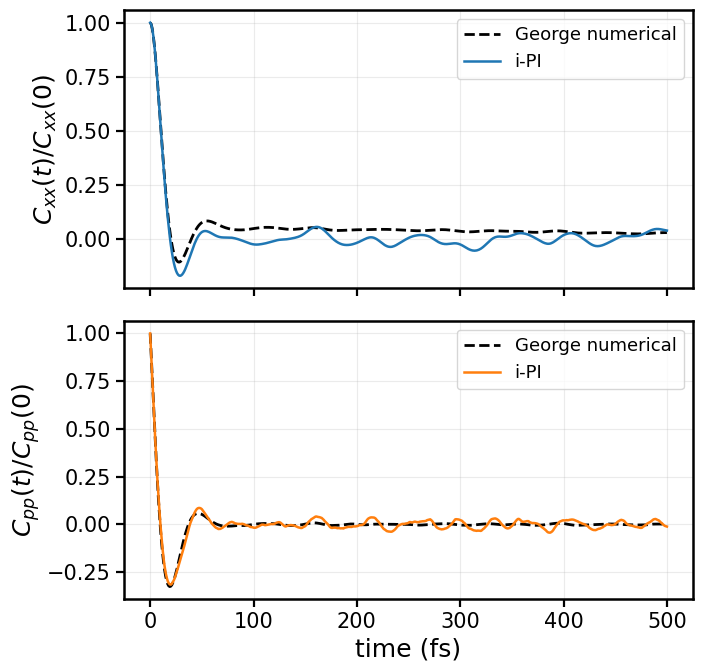

Wrote: /Users/u1865573/work/2026/friction-ipi/04_george_code_benchmark/ipi_harmonic_tcf_benchmark/doublewell_george_vs_ipi.png
Wrote: /Users/u1865573/work/2026/friction-ipi/04_george_code_benchmark/ipi_harmonic_tcf_benchmark/doublewell_george_vs_ipi_errors.csv
double well rms(Cxx) = 4.682951e-02
double well rms(Cpp) = 1.863156e-02


In [ ]:
dw_x, dw_p = load_doublewell_series(dw_run_dir)
dw_max_lag = min(len(dw_x) // 4, int(u.str2base(f"{dw_lag_time_fs} fs") / (dw_stride * dw_dt_au)) + 1)
dw_t_ipi_fs = np.arange(dw_max_lag) * dw_stride * dw_dt_au / u.str2base("1 fs")

dw_cxx_ipi = estimate_tcf(dw_x, dw_x, dw_max_lag)
dw_cpp_ipi = estimate_tcf(dw_p, dw_p, dw_max_lag)
dw_cxx_ipi_n = dw_cxx_ipi / dw_cxx_ipi[0]
dw_cpp_ipi_n = dw_cpp_ipi / dw_cpp_ipi[0]

dw_cxx_ref_local = dw_cxx_ref_n[:dw_max_lag]
dw_cpp_ref_local = dw_cpp_ref_n[:dw_max_lag]
dw_t_ref_local = dw_t_ref_fs[:dw_max_lag]

dw_err_cxx = np.sqrt(np.mean((dw_cxx_ipi_n - dw_cxx_ref_local) ** 2))
dw_err_cpp = np.sqrt(np.mean((dw_cpp_ipi_n - dw_cpp_ref_local) ** 2))

fig, axes = plt.subplots(2, 1, figsize=(7, 7), sharex=True)
axes[0].plot(dw_t_ref_local, dw_cxx_ref_local, color="black", ls="--", lw=2.0, label="George numerical")
axes[0].plot(dw_t_ipi_fs, dw_cxx_ipi_n, color="tab:blue", lw=1.8, label="i-PI")
axes[1].plot(dw_t_ref_local, dw_cpp_ref_local, color="black", ls="--", lw=2.0, label="George numerical")
axes[1].plot(dw_t_ipi_fs, dw_cpp_ipi_n, color="tab:orange", lw=1.8, label="i-PI")
axes[0].set_ylabel(r"$C_{xx}(t) / C_{xx}(0)$")
axes[1].set_ylabel(r"$C_{pp}(t) / C_{pp}(0)$")
axes[1].set_xlabel("time (fs)")
axes[0].grid(alpha=0.25)
axes[1].grid(alpha=0.25)
axes[0].legend()
axes[1].legend()
fig.tight_layout()
fig.savefig(ROOT / "doublewell_george_vs_ipi.png", dpi=200)
plt.show()

with (ROOT / "doublewell_george_vs_ipi_errors.csv").open("w", newline="") as handle:
    writer = csv.writer(handle)
    writer.writerow(["rms_cxx", "rms_cpp"])
    writer.writerow([dw_err_cxx, dw_err_cpp])

print("Wrote:", ROOT / "doublewell_george_vs_ipi.png")
print("Wrote:", ROOT / "doublewell_george_vs_ipi_errors.csv")
print(f"double well rms(Cxx) = {dw_err_cxx:.6e}")
print(f"double well rms(Cpp) = {dw_err_cpp:.6e}")